In [1]:
from src.agent.langgraph_agent import ai_agent, external_kb_meta
from langchain_core.messages import AIMessage, HumanMessage

c:\Users\subin\.conda\envs\agentic.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2384.41it/s]


[ 2026-05-15 16:19:31,975 ]: INFO - 228 CrossEncoder - Use pytorch device: cpu


In [2]:
CONFIG = {'configurable': {'thread_id': "004"}}

In [3]:
user_input = "What is the current stock updates of Amazon?"

initial_state = {
        "messages": [HumanMessage(content=user_input)],
        "external_kb_meta": external_kb_meta
    }

In [4]:
response = ai_agent.invoke(initial_state, config=CONFIG)       #type: ignore
agent_message = response["messages"][-1].content
print(agent_message)

[ 2026-05-15 16:20:19,800 ]: INFO - 1025 _client - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"
[ 2026-05-15 16:20:20,281 ]: INFO - 1025 _client - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


APIError: Tool choice is none, but model called a tool

In [4]:
!pip install -U wikipedia
!pip install -U langchain-community

   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.5 MB 5.7 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 2.2 MB/s eta 0:00:01
   ------------ --------------------------- 0.8/2.5 MB 2.2 MB/s eta 0:00:01
   ---------------- ----------------------- 1.0/2.5 MB 1.3 MB/s eta 0:00:02
   ---------------------------- ----------- 1.8/2.5 MB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 2.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   -------------------- ------------------- 0.5/1.0 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 1.0/1.0 MB 2.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/548.1 kB ? eta -:--:--
   -------------------------------------- - 524.3/548.1 kB 3.4 MB/s eta 0:00:01
   -------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
embedchain 0.1.128 requires langchain-community<0.4.0,>=0.3.1, but you have langchain-community 0.4.1 which is incompatible.
embedchain 0.1.128 requires langchain-openai<0.3.0,>=0.2.1, but you have langchain-openai 0.3.28 which is incompatible.
langchain 0.3.26 requires langchain-core<1.0.0,>=0.3.66, but you have langchain-core 1.4.0 which is incompatible.
langchain 0.3.26 requires langchain-text-splitters<1.0.0,>=0.3.8, but you have langchain-text-splitters 1.1.2 which is incompatible.
langchain-chroma 0.2.4 requires chromadb>=1.0.9, but you have chromadb 0.5.23 which is incompatible.
langchain-cohere 0.3.5 requires langchain-core<0.4.0,>=0.3.27, but you have langchain-core 1.4.0 which is incompatible.
langchain-experimental 0.3.4 requires langchain-community<0.4.0,>=0.3.0, but you have langchain-community 0.4.1 

In [14]:
import wikipedia

def wiki_tool(query: str):
    try:
        return wikipedia.summary(query, sentences=30)
    except Exception as e:
        return f"Wikipedia error: {str(e)}"

In [16]:
wiki_tool("Biography of Donald Trump")

'This bibliography of Donald Trump is a list of written and published works, by and about Donald Trump, the 45th and 47th president of the United States. Due to the sheer volume of books about Trump, the titles listed here are limited to non-fiction books about Trump or his presidency, published by notable authors and scholars. Tertiary sources (including textbooks and juvenile literature), satire, and self-published books are excluded.\nPrior to his 2016 presidential campaign, Trump was widely known by the American public and media establishment, and was already the focus of many books describing his life as a businessman, media personality, and politician. Biographer Michael D\'Antonio observed in Never Enough: Donald Trump and the Pursuit of Success (2015) that Trump "has been a topic of conversation in America for almost 40 years. No one in the world of business – not Bill Gates, Steve Jobs or Warren Buffett – has been as famous as Trump for as long." Almost one year after his inau

In [21]:
wikipedia.set_lang("en")

def wikipedia_tool(query):
    """
    Lightweight Wikipedia tool for LLMs.
    Returns only compact useful information.
    """

    try:
        # Search first
        results = wikipedia.search(query)

        if not results:
            return "No Wikipedia page found."

        # Take best match
        page_title = results[0]

        # Fetch page
        page = wikipedia.page(page_title, auto_suggest=False)

        # Compact response
        data = {
            "title": page.title,
            "summary": wikipedia.summary(page_title, sentences=10),
            "url": page.url,
            "sections": page.sections[:10],  # optional
        }

        return data

    except wikipedia.exceptions.DisambiguationError as e:
        return {
            "error": "DisambiguationError",
            "options": e.options[:5]
        }

    except Exception as e:
        return {"error": str(e)}


# Example
result = wikipedia_tool("Donald Trump")

print(result)

{'title': 'Donald Trump', 'summary': "Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman who is the 47th president of the United States. A member of the Republican Party, he served as the 45th president from 2017 to 2021.\nBorn into a wealthy New York City family, Trump graduated from the University of Pennsylvania in 1968 with a bachelor's degree in economics. He became the president of his family's real estate business in 1971, renamed it the Trump Organization, and began acquiring and building skyscrapers, hotels, casinos, and golf courses. He launched side ventures, many licensing the Trump name, and filed for six business bankruptcies in the 1990s and 2000s. From 2004 to 2015, he hosted the reality television show The Apprentice, bolstering his fame as a billionaire. Presenting himself as a political outsider, Trump won the 2016 presidential election against Democratic Party nominee Hillary Clinton.\nDuring his first presidency, Tr

In [1]:
from langchain_core.prompts import ChatPromptTemplate
from src.agent.prompt import web_agent_prompt
from langchain_core.prompts import ChatPromptTemplate

c:\Users\subin\.conda\envs\agentic.env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from langchain_groq import ChatGroq
web_agent_llm =  ChatGroq(model="openai/gpt-oss-20b", temperature=0.4)

In [3]:
from src.tools.tools import news_search, wiki_search, tavily_search

tools = [news_search, wiki_search, tavily_search]

web_agent_with_tools = web_agent_llm.bind_tools(tools)

chat_template = ChatPromptTemplate(
    [
        ("system", web_agent_prompt),
        ("human", "Question: {query}")
    ],
    input_variables=["query"]
)

chain = chat_template | web_agent_with_tools 

query = "Which team won the IPL match yesterday?"
web_results = chain.invoke({"query": query})

c:\Users\subin\.conda\envs\agentic.env\Lib\site-packages\langgraph\checkpoint\base\__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


[ 2026-05-17 21:51:20,669 ]: INFO - 1025 _client - HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


In [4]:
web_results

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Which team won the IPL match yesterday?" We need to determine which IPL match occurred yesterday (the day before the current date). The current date is 2026-05-17. So yesterday is 2026-05-16. We need to find out which IPL match took place on 2026-05-16 and which team won. We need to search. Use web search. Use tavily_search or news_search. Let\'s try news_search first.', 'tool_calls': [{'id': 'fc_5188c4de-5060-4cea-9904-afffba7c9da1', 'function': {'arguments': '{"query":"IPL match 2026-05-16 result"}', 'name': 'news_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 132, 'prompt_tokens': 532, 'total_tokens': 664, 'completion_time': 0.137703701, 'prompt_time': 0.027358158, 'queue_time': 0.050994592, 'total_time': 0.165061859, 'completion_tokens_details': {'reasoning_tokens': 100}}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_3d587a02fb', 'service_tier': 

In [2]:
%cd ..

d:\My Projects\Multi-AI Agent


In [3]:
import os, sys
from typing import Optional
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AIMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.types import interrupt
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool
from sentence_transformers import CrossEncoder
from pathlib import Path
import google.generativeai as genai
from dotenv import load_dotenv
load_dotenv()

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from transformers import logging as transformers_logging
transformers_logging.set_verbosity_error()
from src.logger import logging
from src.exception.exception_handler import AppException
from utils import get_checkpointer
from src.agent.helpers import *
from src.tools.mcp.search_tools import retriever, tavily_search, news_search, wiki_search, weather_tool, stock_finance_tool
from src.tools.n8n.workspace_tools import gmail_agent, calender_agent
from src.agent.prompt import (assistant_system_prompt, supervisor_system_prompt, research_agent_system_prompt,
                              answer_agent_system_prompt, vision_agent_system_prompt)
from src.agent.schema import (AssistantDecision, SupervisorDecision, WorkspaceAgentDecission, AnswerAgentResponse, TaskResult)


# AGENT STATE SCHEMA
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    query: str
    external_kb_meta: dict
    plan: list[str]
    completed_steps: list[str]
    task_results: Annotated[list[TaskResult], reduce_list]
    delegation_instructions: Annotated[dict[str, str], update_dict]
    next_nodes: list[str]
    uploaded_doc: Optional[str]
    uploaded_doc_summary: Optional[str]
    image_data: Optional[list]
    reference_context_ids: Optional[list[int]]
    reference_note: Optional[str]
    doc_context_mode: Optional[str]
    pending_action: Optional[dict]
    requires_hitl: bool
    hitl_feedback: Optional[str]
    is_final_step: bool


# INITIALIZE LLMs
assistant_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite", temperature=0.5).with_structured_output(AssistantDecision)
supervisor_llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.2).with_structured_output(SupervisorDecision)
research_llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0.3)
workspace_llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0.3)
answer_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.6).with_structured_output(AnswerAgentResponse)

genai.configure(api_key=os.getenv("GOOGLE_API_KEY"))                        #type: ignore
vision_llm = genai.GenerativeModel("gemini-2.5-flash")                      #type: ignore

# load reranker model for retriever tool
reranker_path = Path("models/bge-reranker-base")
reranker = CrossEncoder(str(reranker_path))

n8n_agents = {"gmail": gmail_agent, "calendar": calender_agent}


# ---------------------------------------------------------------------------
# HELPERS -- standardized interrupt/resume contract
# ---------------------------------------------------------------------------
# Every HITL pause now uses the SAME payload shape going out:
#   {"type": "approval", "message": <str>, ...extra context...}
# And the SAME shape coming back from the resume (Command(resume=...)):
#   {"approved": bool, "feedback": Optional[str]}
def _parse_resume_decision(decision) -> tuple[bool, Optional[str]]:
    """Normalizes whatever comes back from interrupt() into (approved, feedback)."""
    if isinstance(decision, dict):
        approved = bool(decision.get("approved"))
        feedback = decision.get("feedback")
        return approved, feedback
    # Fallback for a raw "y"/"n" string, just in case the frontend sends that.
    if isinstance(decision, str):
        return decision.strip().lower() in ("y", "yes", "true", "1"), None
    return False, None


# NODE 0: GENERAL ASSISTANT
def assistant_node(state: AgentState):
    """
    Context-aware front door assistant. Sees chat history (nothing downstream of this node does).
    Handles chitchat, ambiguity, follow-ups directly, and reframes task queries into self-contained
    form before handing off to the supervisor. Also picks which past turns (by number) should be
    carried forward for downstream agents.
    """
    query = state.get("query", "User query not found.")
    is_doc_uploaded = bool(state.get("uploaded_doc"))
    is_image_uploaded = bool(state.get("image_data"))

    indexed_history, _ = build_indexed_turns(state.get("messages", []))

    response: Optional[AssistantDecision] = None
    try:
        chat_template = ChatPromptTemplate(
            [
                ("system", assistant_system_prompt),
                ("human",
                 "Previous Conversations (numbered turns -- use these numbers if you need to reference one):\n"
                 "{chat_history} \n\nCurrent user query: {query}\n\n"
                 "Document uploaded: {is_doc_uploaded}\nImage uploaded: {is_image_uploaded}")
            ],
            input_variables=["chat_history", "query", "is_doc_uploaded", "is_image_uploaded"]
        )

        chain = chat_template | assistant_llm
        response = chain.invoke({
            "chat_history": indexed_history,
            "query": query,
            "is_doc_uploaded": is_doc_uploaded,
            "is_image_uploaded": is_image_uploaded,
        })                                                          #type: ignore

    except Exception as e:
        logging.error(f"Error in assistant node: {e}", exc_info=True)
        response = None

    if not response or response.decision == "task":
        resolved_query = response.reframed_query if response and response.reframed_query else query
        ref_ids = response.reference_context_ids if response else None
        return {
            "query": resolved_query,
            "next_nodes": ["supervisor"],
            "plan": [],
            "completed_steps": [],
            "task_results": RESET,
            "delegation_instructions": RESET,
            "reference_context_ids": ref_ids if ref_ids else None,
            "reference_note": response.reference_note if (response and ref_ids) else None,
            "pending_action": None,
            "hitl_feedback": None,
            "is_final_step": False
        }

    if response.decision == "vision":
        return {
            "query": query,
            "next_nodes": ["vision"],
        }

    # for direct_answer / ambiguous
    return {
        "messages": [AIMessage(content=response.response)],
        "next_nodes": ["FINISH"],
    }


# NODE 1: THE SUPERVISOR ORCHESTRATOR
def supervisor_node(state: AgentState):
    query = state.get("query", "")
    if not query and state.get("messages"):
        query = str(state["messages"][-1].content)

    task_results = deduplicate_task_results(state.get("task_results", []))
    current_plan = state.get("plan", [])
    completed_steps = state.get("completed_steps", [])
    task_results_str = "\n".join(format_task_result(r) for r in task_results) if task_results else "None"

    context = build_supervisor_context(state)

    try:
        hitl_feedback = state.get("hitl_feedback", None)

        chat_template = ChatPromptTemplate(
            [
                ("system", supervisor_system_prompt),
                ("human",
                 "Original Question: {query}\n\n"
                 "Internal KB: {kb_context}\n\nUser uploaded document summary: {doc_context}\n\n"
                 "Referenced context (from assistant): {reference_note}\n\n"
                 "Current Plan:\n{plan}\n\nCompleted Steps:\n{completed_steps}\n\n"
                 "Task Results so far:\n{task_results}\n\n"
                 "User feedback on the most recently rejected action (if any -- revise your next "
                 "delegation instruction to address this before retrying):\n{hitl_feedback}")
            ],
            input_variables=["query", "kb_context", "doc_context", "reference_note",
                              "plan", "completed_steps", "task_results", "hitl_feedback"]
        )

        chain = chat_template | supervisor_llm
        response: SupervisorDecision = chain.invoke({
            "query": query,
            "plan": "\n".join(f"- {step}" for step in current_plan) if current_plan else "None",
            "completed_steps": "\n".join(f"- {step}" for step in completed_steps) if completed_steps else "None",
            "task_results": task_results_str,
            "hitl_feedback": hitl_feedback or "None",
            **context,
        })                       # type: ignore

        # SAFETY CHECK: never let the supervisor emit a parallel fan-out when a HITL confirmation is required 
        next_nodes = response.next_nodes
        if response.requires_hitl and len(next_nodes) > 1:
            logging.error(
                f"Supervisor requested parallel next_nodes {next_nodes} with requires_hitl=True; "
                f"collapsing to the first node only."
            )
            next_nodes = next_nodes[:1]

        return {
            "plan": response.plan,
            "completed_steps": response.completed_steps,
            "next_nodes": next_nodes,
            "delegation_instructions": {"__replace__": True, "entries": response.delegation_instructions},
            "doc_context_mode": response.doc_context_mode,
            "requires_hitl": response.requires_hitl,
            "is_final_step": response.final_step,
            "hitl_feedback": None,
            "pending_action": None,
        }
    except Exception as e:
        logging.error(f"Error in Supervisor node: {e}", exc_info=True)
        raise AppException(e, sys)


# NODE 2: WORKSPACE AGENT
def workspace_agent(state: AgentState):
    is_final_step = bool(state.get("is_final_step"))
    requires_hitl = bool(state.get("requires_hitl"))

    instruction = state.get("delegation_instructions", {}).get("workspace_agent", "No instruction provided")
    referenced_context = get_referenced_context(state, state.get("reference_context_ids"))
    feedback = state.get("hitl_feedback")

    # Prior steps this task (research findings, earlier workspace results, etc.) -- read directly.
    prior_results = deduplicate_task_results(state.get("task_results", []))
    task_context = "\n".join(format_task_result(r) for r in prior_results) if prior_results else ""

    full_instruction = f"CONTEXT:\n{referenced_context}\n\nTASK CONTEXT:\n{task_context}\n\nCURRENT INSTRUCTION: {instruction}"
    if feedback:
        full_instruction += f"\n\nUSER FEEDBACK ON PREVIOUS ATTEMPT (revise accordingly): {feedback}"

    try:
        agent_selection_prompt = ChatPromptTemplate.from_messages([
            ("system",
             "Analyze the request and choose which workspace agent (gmail or calendar, or 'none' if neither "
             "applies) needs to be called to serve this request. Also specify the concrete action it should take."),
            ("human", "{instruction}"),
        ])

        selection: WorkspaceAgentDecission = (agent_selection_prompt | workspace_llm).invoke({
            "instruction": full_instruction
        })                                      #type:ignore

        if selection.agent == "none" or selection.agent not in n8n_agents:
            return {
                "task_results": [task_result(
                    agent="workspace_agent",
                    task=instruction,
                    status="error",
                    output="No matching workspace tool (gmail/calendar) could handle this instruction.",
                )],
                "next_nodes": ["supervisor"],
                "hitl_feedback": None,
                "pending_action": None,
            }

        agent = n8n_agents[selection.agent]
        action = selection.action

        if requires_hitl:
            decision = interrupt({
                "type": "approval",
                "message": f"{selection.agent} is about to: {action}. Approve? (y/n)",
                "pending_action": {"agent": selection.agent, "action": action, "instruction": instruction},
            })
            approved, revision_feedback = _parse_resume_decision(decision)

            if not approved:
                return {
                    "messages": [AIMessage(
                        content="Understood -- I won't proceed with that action. Let me know how you'd like it revised."
                    )],
                    "next_nodes": ["supervisor"],
                    "hitl_feedback": revision_feedback or "User rejected the proposed workspace action.",
                    "pending_action": {"agent": selection.agent, "action": action, "instruction": instruction},
                }

        result = agent.invoke(full_instruction)

        update = {
            "task_results": [task_result(
                agent="workspace_agent", task=instruction, status="success", output=result["response"]
            )],
            "hitl_feedback": None,
            "pending_action": None,
        }

        if is_final_step:
            update["messages"] = [AIMessage(content=result["response"])]
            update["next_nodes"] = ["FINISH"]
        else:
            update["next_nodes"] = ["supervisor"]

        return update

    except Exception as e:
        logging.error(f"Error in workspace_agent node: {e}", exc_info=True)
        return {
            "task_results": [task_result(agent="workspace_agent", task=instruction, status="error", output=str(e))],
            "next_nodes": ["supervisor"],
        }


# NODE 3: RESEARCH NODE
def research_node(state: AgentState):
    instruction = state.get("delegation_instructions", {}).get("research_agent", state.get("query", ""))
    is_final_step = bool(state.get("is_final_step"))

    @tool
    def internal_kb_search(query: str):
        """Search the INTERNAL business knowledge base (RAG) for relevant documents.
        This is NOT for user-uploaded PDFs -- those are handled directly via `uploaded_doc`
        in answer_node, never RAG."""
        index_name = state.get("external_kb_meta", {}).get("topic", "")
        if not index_name:
            return "No internal knowledge base is available. Use web search tools instead."
        docs = retriever.invoke({"query": query, "index_name": index_name, "reranker": reranker})
        return docs if docs else "No relevant documents found in internal knowledge base."

    tools = [internal_kb_search, tavily_search, news_search, wiki_search, weather_tool, stock_finance_tool]

    system_prompt = research_agent_system_prompt
    kb_meta = state.get("external_kb_meta", {})
    if kb_meta.get("available"):
        system_prompt = (
            f"{research_agent_system_prompt}\n\nNOTE: An internal knowledge base is available on topic "
            f"'{kb_meta.get('topic', 'unknown')}'. If the instruction relates to this topic, use the "
            f"`internal_kb_search` tool."
        )

    agent = create_agent(
        model=research_llm,
        tools=tools,
        system_prompt=system_prompt,
    )
    config = RunnableConfig({"recursion_limit": 14})

    try:
        response = agent.invoke({"messages": [{"role": "user", "content": instruction}]}, config=config)
        result = response["messages"][-1].content

        if is_final_step:
            return {
                "messages": [AIMessage(content=result)],
                "next_nodes": ["FINISH"],
            }
        else:
            return {
                "task_results": [task_result(
                    agent="research_agent", task=instruction, status="success", output=result
                )],
                "next_nodes": ["supervisor"],
            }

    except Exception as e:
        logging.error(f"Error in research node: {e}", exc_info=True)
        return {
            "task_results": [task_result(agent="research_agent", task=instruction, status="error", output=str(e))],
            "next_nodes": ["supervisor"],
        }


# NODE 4: ANSWER NODE
def answer_node(state: AgentState):
    query = state.get("query")
    instruction = state.get("delegation_instructions", {}).get("answer_agent", state.get("query", ""))
    doc_context_mode = state.get("doc_context_mode")
    referenced_context = get_referenced_context(state, state.get("reference_context_ids"))
    requires_hitl = bool(state.get("requires_hitl"))
    is_final_step = bool(state.get("is_final_step"))
    feedback = state.get("hitl_feedback")

    try:
        task_results = deduplicate_task_results(state.get("task_results", []))
        web_results = [format_task_result(r) for r in task_results if r.get("agent") == "research_agent"]
        workspace_results = [format_task_result(r) for r in task_results if r.get("agent") == "workspace_agent"]

        if doc_context_mode == "document":
            uploaded_doc = state.get("uploaded_doc")

            prompt = (
                "Uploaded Document:\n{uploaded_doc}\n\n"
                "WEB RESULTS:\n{web_results}\n\n"
                "Referenced Past Turns:\n{referenced_context}\n\n"
                "Instruction from your Supervisor:\n{instruction}\n\n"
                "ORIGINAL USER QUESTION:\n{query}\n\n"
                "PRIOR FEEDBACK (revise accordingly if present):\n{feedback}"
            )
            variables = {
                "uploaded_doc": uploaded_doc or "None",
                "web_results": "\n".join(web_results) if web_results else "None",
                "referenced_context": referenced_context or "None",
                "instruction": instruction,
                "query": query,
                "feedback": feedback or "None",
            }

        else:
            prompt = (
                "WEB SEARCH RESULTS:\n{web_results}\n\n"
                "WORKSPACE RESULTS:\n{workspace_results}\n\n"
                "Referenced Past Turns:\n{referenced_context}\n\n"
                "Instruction from your Supervisor:\n{instruction}\n\n"
                "ORIGINAL USER QUESTION:\n{query}\n\n"
                "PRIOR FEEDBACK (revise accordingly if present):\n{feedback}"
            )
            variables = {
                "web_results": "\n".join(web_results) if web_results else "None",
                "workspace_results": "\n".join(workspace_results) if workspace_results else "None",
                "referenced_context": referenced_context or "None",
                "instruction": instruction,
                "query": query,
                "feedback": feedback or "None",
            }

        chat_template = ChatPromptTemplate(
            [
                ("system", answer_agent_system_prompt),
                ("human", prompt),
            ],
            input_variables=[],
        )

        chain = chat_template | answer_llm
        response: AnswerAgentResponse = chain.invoke(variables)                                                    #type: ignore
        final_answer = response.final_answer or "I apologize, but I was unable to generate a proper answer."

        if requires_hitl:
            decision = interrupt({
                "type": "approval",
                "message": "Here is the drafted response -- do you approve it? (y/n)",
                "draft": final_answer,
            })
            approved, revision_feedback = _parse_resume_decision(decision)

            if not approved:
                return {
                    "messages": [AIMessage(content="Got it -- I won't finalize this version. Let me know what to change.")],
                    "next_nodes": ["supervisor"],
                    "hitl_feedback": revision_feedback or "User rejected the drafted answer.",
                }

        update = {
            "task_results": [task_result(
                agent="answer_agent", task=instruction, status="success", output=final_answer
            )],
            "hitl_feedback": None,
        }

        if is_final_step:
            update["messages"] = [AIMessage(content=final_answer)]
            update["next_nodes"] = ["FINISH"]
        else:
            update["next_nodes"] = ["supervisor"]

        return update

    except Exception as e:
        logging.error(f"Error in answer node: {e}", exc_info=True)
        return {
            "messages": [AIMessage(content="I apologize, but I encountered an error generating the final answer. Please try again later.")],
            "next_nodes": ["FINISH"],
        }


# NODE 5: VISION NODE
def vision_node(state: AgentState):
    try:
        image_data = state.get("image_data")
        if image_data:
            response = vision_llm.generate_content([vision_agent_system_prompt, state["query"], image_data[0]])
            return {"messages": [AIMessage(content=response.text)]}
        return {"messages": [AIMessage(content="I couldn't find an image to analyze. Please try uploading it again.")]}

    except Exception as e:
        logging.error(f"Error in vision node: {e}", exc_info=True)
        return {"messages": [AIMessage(content="I apologize, but I encountered an error processing the image. Please try again later.")]}


# ---------------------------------------------------------------------------
# CONDITIONAL ROUTING FUNCTIONS
# ---------------------------------------------------------------------------
def route_from_assistant(state: AgentState) -> str:
    nodes = state.get("next_nodes", ["supervisor"])
    if "FINISH" in nodes:
        return END
    if "vision" in nodes:
        return "vision"
    return "supervisor"


def route_by_next_nodes(state: AgentState) -> list[str]:
    """
    Generic router: reads `next_nodes` from state and either fans out to those
    node names or terminates. Used by supervisor, workspace_agent, research_agent,
    and answer_agent -- any node whose own logic decides where to go next.
    Each of those nodes is responsible for NEVER emitting more than one node
    name here when requires_hitl is True for the step in progress (enforced
    defensively in supervisor_node; workspace_agent/answer_agent are single
    nodes by construction so this can't arise for them).
    """
    nodes = state.get("next_nodes", ["FINISH"])
    if "FINISH" in nodes:
        return [END]
    return nodes


# ---------------------------------------------------------------------------
# BUILD GRAPH WORKFLOW
# ---------------------------------------------------------------------------

graph = StateGraph(AgentState)

graph.add_node("assistant", assistant_node)
graph.add_node("supervisor", supervisor_node)
graph.add_node("research_agent", research_node)
graph.add_node("workspace_agent", workspace_agent)
graph.add_node("answer_agent", answer_node)
graph.add_node("vision", vision_node)

graph.add_edge(START, "assistant")
graph.add_conditional_edges("assistant", route_from_assistant)
graph.add_conditional_edges("supervisor", route_by_next_nodes)

graph.add_conditional_edges("research_agent", route_by_next_nodes)
graph.add_conditional_edges("workspace_agent", route_by_next_nodes)
graph.add_conditional_edges("answer_agent", route_by_next_nodes)

graph.add_edge("vision", END)

checkpointer = get_checkpointer()
ai_agent = graph.compile(checkpointer=checkpointer)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1217.68it/s]


[ 2026-07-14 19:31:41,695 ]: INFO - 228 CrossEncoder - Use pytorch device: cpu


In [3]:
!pip install ipython

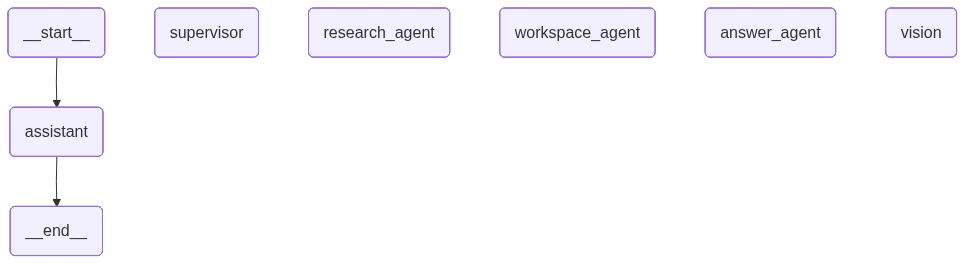

In [5]:
from IPython.display import Image
Image(ai_agent.get_graph().draw_mermaid_png())

In [2]:
import redis

r = redis.Redis(
    host='faithful-profit-macroglossy-21054.db.redis.io',
    port=14983,
    decode_responses=True,
    username="default",
    password="7gPXiFMkUYv87alorLayKCVar24WU7MK",
)

r.set("name", "Subinoy")

print(r.get("name"))

Subinoy


In [5]:
r.set("otp", "1234", ex=10)

True

In [7]:
print(r.get("otp"))

None
